In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [32]:
# Load the dataset
data = pd.read_csv('archive/Reviews.csv')

data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [34]:
data.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

In [35]:
data = data.dropna()

In [36]:
data.isnull().sum()

Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   0
Text                      0
dtype: int64

In [37]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 568401 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568401 non-null  int64 
 1   ProductId               568401 non-null  object
 2   UserId                  568401 non-null  object
 3   ProfileName             568401 non-null  object
 4   HelpfulnessNumerator    568401 non-null  int64 
 5   HelpfulnessDenominator  568401 non-null  int64 
 6   Score                   568401 non-null  int64 
 7   Time                    568401 non-null  int64 
 8   Summary                 568401 non-null  object
 9   Text                    568401 non-null  object
dtypes: int64(5), object(5)
memory usage: 47.7+ MB


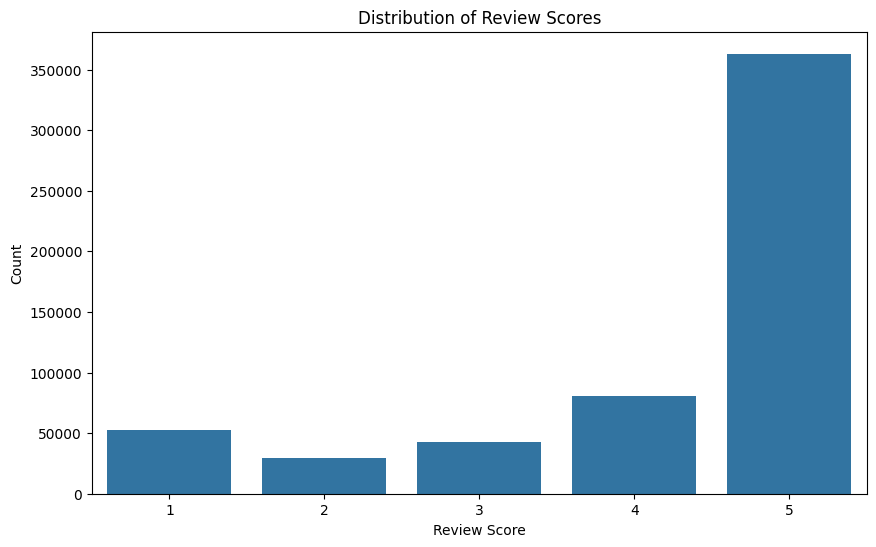

In [38]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Score', data=data)
plt.title('Distribution of Review Scores')
plt.xlabel('Review Score')
plt.ylabel('Count')
plt.show()  

In [39]:
data['Text'] = data['Text'].str.lower()
# Remove punctuation, numbers, and extra whitespace
data['Text'] = data['Text'].str.replace('[^\w\s]', '', regex=True)

# Remove numbers and extra whitespace
data['Text'] = data['Text'].str.replace('\d+', '', regex=True)
data['Text'] = data['Text'].str.replace('\s+', ' ', regex=True).str.strip()

data.head()

<>:3: SyntaxWarning: invalid escape sequence '\w'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\w'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/var/folders/6b/jgk7rrk92zqdc3hd7dxmz75h0000gn/T/ipykernel_79250/863525579.py:3: SyntaxWarning: invalid escape sequence '\w'
  data['Text'] = data['Text'].str.replace('[^\w\s]', '', regex=True)
/var/folders/6b/jgk7rrk92zqdc3hd7dxmz75h0000gn/T/ipykernel_79250/863525579.py:6: SyntaxWarning: invalid escape sequence '\d'
  data['Text'] = data['Text'].str.replace('\d+', '', regex=True)
/var/folders/6b/jgk7rrk92zqdc3hd7dxmz75h0000gn/T/ipykernel_79250/863525579.py:7: SyntaxWarning: invalid escape sequence '\s'
  data['Text'] = data['Text'].str.replace('\s+', ' ', regex=True).str.strip()


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,i have bought several of the vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,product arrived labeled as jumbo salted peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",this is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,if you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,great taffy at a great price there was a wide ...


In [40]:
nltk.download('punkt')
from nltk.tokenize import word_tokenize

data['Tokens'] = data['Text'].apply(word_tokenize)

data.head()

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/madhumithakatam/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Tokens
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,i have bought several of the vitality canned d...,"[i, have, bought, several, of, the, vitality, ..."
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,product arrived labeled as jumbo salted peanut...,"[product, arrived, labeled, as, jumbo, salted,..."
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",this is a confection that has been around a fe...,"[this, is, a, confection, that, has, been, aro..."
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,if you are looking for the secret ingredient i...,"[if, you, are, looking, for, the, secret, ingr..."
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,great taffy at a great price there was a wide ...,"[great, taffy, at, a, great, price, there, was..."


In [41]:
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(tokens):
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens) 

data['Processed_Text'] = data['Tokens'].apply(preprocess_text)

data.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/madhumithakatam/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/madhumithakatam/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Tokens,Processed_Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,i have bought several of the vitality canned d...,"[i, have, bought, several, of, the, vitality, ...",bought several vitality canned dog food produc...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,product arrived labeled as jumbo salted peanut...,"[product, arrived, labeled, as, jumbo, salted,...",product arrived labeled jumbo salted peanutsth...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",this is a confection that has been around a fe...,"[this, is, a, confection, that, has, been, aro...",confection around century light pillowy citrus...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,if you are looking for the secret ingredient i...,"[if, you, are, looking, for, the, secret, ingr...",looking secret ingredient robitussin believe f...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,great taffy at a great price there was a wide ...,"[great, taffy, at, a, great, price, there, was...",great taffy great price wide assortment yummy ...


In [42]:
drop_columns = ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Time', 'Tokens', 'Text']


data = data.drop(columns=drop_columns, errors='ignore')

data.head()

,Score,Summary,Processed_Text
0,5,Good Quality Dog Food,bought several vitality canned dog food produc...
1,1,Not as Advertised,product arrived labeled jumbo salted peanutsth...
2,4,"""Delight"" says it all",confection around century light pillowy citrus...
3,2,Cough Medicine,looking secret ingredient robitussin believe f...
4,5,Great taffy,great taffy great price wide assortment yummy ...


In [43]:
data = data[data['Score'] < 3]

data.head()

,Score,Summary,Processed_Text
1,1,Not as Advertised,product arrived labeled jumbo salted peanutsth...
3,2,Cough Medicine,looking secret ingredient robitussin believe f...
12,1,My Cats Are Not Fans of the New Food,cat happily eating felidae platinum two year g...
16,2,poor taste,love eating good watching tv looking movie swe...
26,1,Nasty No flavor,candy red flavor plan chewy would never buy


In [ ]:
data.to_csv('processed_reviews.csv', index=False)

In [2]:
import pandas as pd

In [3]:
data = pd.read_csv('processed_reviews.csv')

data.head()

,Score,Summary,Processed_Text
0,1,Not as Advertised,product arrived labeled jumbo salted peanutsth...
1,2,Cough Medicine,looking secret ingredient robitussin believe f...
2,1,My Cats Are Not Fans of the New Food,cat happily eating felidae platinum two year g...
3,2,poor taste,love eating good watching tv looking movie swe...
4,1,Nasty No flavor,candy red flavor plan chewy would never buy


In [6]:
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(data['Processed_Text'])
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X)
data['Cluster'] = kmeans.labels_

## BERT Embeddings

In [8]:
!pip install sentence-transformers
from sentence_transformers import SentenceTransformer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 33.9 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 616.3/616.3 kB 24.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 34.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 35.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [sentence-transformers]ence-transformers]


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 18072.85it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [10]:
df = pd.read_csv('processed_reviews.csv')


In [11]:
texts = df["Processed_Text"].astype(str).tolist()

embeddings = model.encode(texts, show_progress_bar=True)

Batches: 100%|██████████| 2563/2563 [01:44<00:00, 24.44it/s]


In [12]:
print(embeddings.shape)

(82007, 384)


In [ ]:
embeddings = np.array(embeddings)
np.save("review_embeddings.npy", embeddings)

In [15]:
!pip install umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [umap-learn]


In [16]:
import umap

In [17]:
embeddings = np.load("review_embeddings.npy")
print(embeddings.shape)

(82007, 384)


In [18]:
reducer = umap.UMAP(
    n_components=5,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

embeddings_reduced = reducer.fit_transform(embeddings)

print(embeddings_reduced.shape)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(82007, 5)


In [19]:
np.save("review_embeddings_umap5.npy", embeddings_reduced)

In [1]:
# !pip install bertopic
from bertopic import BERTopic


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df = pd.read_csv("processed_reviews.csv")
texts = df["Processed_Text"].astype(str).tolist()

embeddings_reduced = np.load("review_embeddings_umap5.npy")
print(embeddings_reduced.shape)

(82007, 5)


In [5]:
topic_model = BERTopic(
    embedding_model=None,
    umap_model=None,
    min_topic_size=50
)

topics, probs = topic_model.fit_transform(texts, embeddings_reduced)

In [6]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,25968,-1_coffee_cat_food_dog,"[coffee, cat, food, dog, cup, like, one, br, b...",[let say like medium roast coffee medium roast...
1,0,2953,0_tea_green_leaf_jasmine,"[tea, green, leaf, jasmine, earl, matcha, lipt...",[bought green tea amazon strong review tried t...
2,1,1507,1_taste_smell_tasted_bad,"[taste, smell, tasted, bad, horrible, stuff, p...",[everyone family share opinion thing taste abs...
3,2,1357,2_peanut_butter_nut_almond,"[peanut, butter, nut, almond, cashew, walnut, ...",[ordered asking wife dieting start make review...
4,3,1202,3_chocolate_cocoa_hot_hershey,"[chocolate, cocoa, hot, hershey, dark, cacao, ...",[taste like chocolate milk really like product...
...,...,...,...,...,...
307,306,51,306_balsamic_vinegar_aged_wine,"[balsamic, vinegar, aged, wine, modena, balsam...",[actual ingredient product listed balsamic vin...
308,307,51,307_cat_vomit_hairball_sore,"[cat, vomit, hairball, sore, diarrhea, vomited...",[know searching internet word temptation vomit...
309,308,50,308_kahlua_kcup_kcups_ferry,"[kahlua, kcup, kcups, ferry, boat, coffee, cup...",[wanted try medium roast kcup thought would gi...
310,309,50,309_egg_slim_listing_jims,"[egg, slim, listing, jims, delice, bahlsen, re...",[bahlsen delice cooky ounce box pack br disapp...


In [7]:
topic_info = topic_model.get_topic_info()
topic_info = topic_info[topic_info.Topic != -1]

top10_topics = topic_info.sort_values("Count", ascending=False).head(10)
print(top10_topics[["Topic", "Count", "Name"]])

    Topic  Count                             Name
1       0   2953         0_tea_green_leaf_jasmine
2       1   1507         1_taste_smell_tasted_bad
3       2   1357       2_peanut_butter_nut_almond
4       3   1202    3_chocolate_cocoa_hot_hershey
5       4   1168     4_cereal_oatmeal_oat_granola
6       5   1061        5_candy_cookie_cooky_ahoy
7       6   1047  6_date_expiration_stale_expired
8       7    888         7_gum_gummy_bear_xylitol
9       8    865      8_popcorn_kernel_pop_popped
10      9    798        9_coconut_water_vita_coco


In [8]:
for _, row in top10_topics.iterrows():
    
    topic_id = row["Topic"]
    count = row["Count"]
    
    keywords = [word for word, _ in topic_model.get_topic(topic_id)[:4]]
    keywords_text = ", ".join(keywords)
    
    print(
        f"Topic {topic_id} contains {count} reviews and primarily discusses "
        f"{keywords_text}."
    )

Topic 0 contains 2953 reviews and primarily discusses tea, green, leaf, jasmine.
Topic 1 contains 1507 reviews and primarily discusses taste, smell, tasted, bad.
Topic 2 contains 1357 reviews and primarily discusses peanut, butter, nut, almond.
Topic 3 contains 1202 reviews and primarily discusses chocolate, cocoa, hot, hershey.
Topic 4 contains 1168 reviews and primarily discusses cereal, oatmeal, oat, granola.
Topic 5 contains 1061 reviews and primarily discusses candy, cookie, cooky, ahoy.
Topic 6 contains 1047 reviews and primarily discusses date, expiration, stale, expired.
Topic 7 contains 888 reviews and primarily discusses gum, gummy, bear, xylitol.
Topic 8 contains 865 reviews and primarily discusses popcorn, kernel, pop, popped.
Topic 9 contains 798 reviews and primarily discusses coconut, water, vita, coco.
